<span style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">An Exception was encountered at '<a href="#papermill-error-cell">In [6]</a>'.</span>

# TRAIT Self-Assessment: Neurotic + Conscientiousness-Suppressor LoRA Combinations

Evaluates how combining a **neurotic LoRA** with a **conscientiousness-suppressor LoRA** at various
scale ratios affects OCEAN + Dark Triad personality trait scores.

Uses the TRAIT benchmark (mirlab/TRAIT) — ABCD multiple-choice self-assessment.

In [1]:
from __future__ import annotations

import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from dotenv import load_dotenv

from src_dev.evals import (
    AdapterConfig,
    InspectBenchmarkSpec,
    ModelSpec,
    SuiteConfig,
    run_eval_suite,
)
from src_dev.evals.personality.analyze_results import ALL_TRAIT_COLS, load_sweep_data

load_dotenv()
%matplotlib inline

# Global seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## Configuration

In [2]:
import subprocess

# Resolve repo root so scratch/ always lands in the right place
REPO_ROOT = Path(
    subprocess.check_output(["git", "rev-parse", "--show-toplevel"]).decode().strip()
)

BASE_MODEL = "meta-llama/Llama-3.1-8B-Instruct"

# HuggingFace dataset repos containing the adapters
NEUROTIC_HF_REPO = "persona-shattering-lasr/monorepo"
NEUROTIC_HF_SUBFOLDER = (
    "fine_tuning/llama-3.1-8B-Instruct/ocean/neuroticism/model/loras/"
    "BEST_SO_FAR_24_March_23b4220/nervousness-souping"
)

CONSCIENTIOUSNESS_HF_REPO = "persona-shattering-lasr/oct-runs-low-conscientiousness-glm45air-v2"
CONSCIENTIOUSNESS_HF_SUBFOLDER = (
    "conscientiousness_low_v2-llama-3.1-8b-it-s223458-94742ca72e77/"
    "lora/conscientiousness_low_v2-persona"
)

CONTROL_HF_REPO = "persona-shattering-lasr/monorepo"
CONTROL_HF_SUBFOLDER = "fine_tuning/llama-3.1-8B-Instruct/control/model/lora/souped"

# Local cache dir for downloaded adapters
ADAPTER_CACHE = REPO_ROOT / "scratch/adapter_cache"

# (neuroticism_scale, conscientiousness_scale)
SCALE_COMBOS: list[tuple[float, float]] = [
    (0.0, 0.0),      # base model
    (1.0, 0.0),      # neurotic only
    (0.0, 1.0),      # consc suppressor only
    (0.5, 0.5),      # equal half blend
    (1.0, 1.0),      # both full strength
    (0.5, 1.0),      # half neurotic, full consc
    (1.0, 0.5),      # full neurotic, half consc
    (1.0, -0.5),     # full neurotic, inverted half consc
    (-0.5, 1.0),     # inverted half neurotic, full consc
]

SAMPLES_PER_TRAIT = 300  # lower for smoke testing (e.g. 5)
TEMPERATURE = 0.0
BATCH_SIZE = 32
MAX_TOKENS = 128
OUTPUT_ROOT = REPO_ROOT / "scratch/evals/trait_adapter_combinations"
RUN_NAME = "neuro_x_consc_combos"
SKIP_COMPLETED = True  # set False to rerun

print(f"Repo root: {REPO_ROOT}")
print(f"Output root: {OUTPUT_ROOT}")


Repo root: /root/persona-shattering-lasr
Output root: /root/persona-shattering-lasr/scratch/evals/trait_adapter_combinations


## Download adapters from HF dataset repos

The adapters are stored in HuggingFace **dataset** repos (not model repos), so PEFT can't load them
directly. We download the adapter files locally first.

In [3]:
from huggingface_hub import snapshot_download


def download_adapter_from_dataset_repo(
    repo_id: str,
    subfolder: str,
    cache_dir: Path,
    label: str,
) -> Path:
    """Download adapter files from a HF dataset repo and return the local path."""
    local_dir = cache_dir / repo_id.replace("/", "_") / subfolder
    if (local_dir / "adapter_config.json").exists():
        print(f"  {label}: already cached at {local_dir}")
        return local_dir

    print(f"  {label}: downloading from {repo_id} / {subfolder} ...")
    snapshot_dir = snapshot_download(
        repo_id=repo_id,
        repo_type="dataset",
        allow_patterns=[f"{subfolder}/*"],
        local_dir=str(cache_dir / repo_id.replace("/", "_")),
    )
    result = Path(snapshot_dir) / subfolder
    assert (result / "adapter_config.json").exists(), (
        f"adapter_config.json not found at {result}. Check subfolder path."
    )
    print(f"  {label}: downloaded to {result}")
    return result


ADAPTER_CACHE.mkdir(parents=True, exist_ok=True)

neurotic_local = download_adapter_from_dataset_repo(
    NEUROTIC_HF_REPO, NEUROTIC_HF_SUBFOLDER, ADAPTER_CACHE, "Neurotic"
)
conscientiousness_local = download_adapter_from_dataset_repo(
    CONSCIENTIOUSNESS_HF_REPO, CONSCIENTIOUSNESS_HF_SUBFOLDER, ADAPTER_CACHE, "Conscientiousness"
)
control_local = download_adapter_from_dataset_repo(
    CONTROL_HF_REPO, CONTROL_HF_SUBFOLDER, ADAPTER_CACHE, "Control"
)

NEUROTIC_ADAPTER = f"local://{neurotic_local.resolve()}"
CONSCIENTIOUSNESS_ADAPTER = f"local://{conscientiousness_local.resolve()}"
CONTROL_ADAPTER = f"local://{control_local.resolve()}"

print(f"\nNeurotic adapter:         {NEUROTIC_ADAPTER}")
print(f"Conscientiousness adapter: {CONSCIENTIOUSNESS_ADAPTER}")
print(f"Control adapter:           {CONTROL_ADAPTER}")


  Neurotic: already cached at /root/persona-shattering-lasr/scratch/adapter_cache/persona-shattering-lasr_monorepo/fine_tuning/llama-3.1-8B-Instruct/ocean/neuroticism/model/loras/BEST_SO_FAR_24_March_23b4220/nervousness-souping
  Conscientiousness: already cached at /root/persona-shattering-lasr/scratch/adapter_cache/persona-shattering-lasr_oct-runs-low-conscientiousness-glm45air-v2/conscientiousness_low_v2-llama-3.1-8b-it-s223458-94742ca72e77/lora/conscientiousness_low_v2-persona
  Control: already cached at /root/persona-shattering-lasr/scratch/adapter_cache/persona-shattering-lasr_monorepo/fine_tuning/llama-3.1-8B-Instruct/control/model/lora/souped

Neurotic adapter:         local:///root/persona-shattering-lasr/scratch/adapter_cache/persona-shattering-lasr_monorepo/fine_tuning/llama-3.1-8B-Instruct/ocean/neuroticism/model/loras/BEST_SO_FAR_24_March_23b4220/nervousness-souping
Conscientiousness adapter: local:///root/persona-shattering-lasr/scratch/adapter_cache/persona-shattering-l

## Build ModelSpecs

In [4]:
def _fmt_scale(s: float) -> str:
    """Format a scale value into a filesystem-safe token: 1.0 -> '1p0', -0.5 -> 'm0p5'."""
    prefix = "m" if s < 0 else ""
    return f"{prefix}{abs(s):.1f}".replace(".", "p")


def make_combo_name(n: float, c: float) -> str:
    if n == 0.0 and c == 0.0:
        return "base"
    return f"n{_fmt_scale(n)}_c{_fmt_scale(c)}"


def make_combo_label(n: float, c: float) -> str:
    if n == 0.0 and c == 0.0:
        return "Base"
    parts = []
    if n != 0.0:
        parts.append(f"{n:g}N$^+$")
    if c != 0.0:
        parts.append(f"{c:g}C$^-$")
    return ", ".join(parts)


def build_model_specs(
    base_model: str,
    neurotic_adapter: str,
    consc_adapter: str,
    scale_combos: list[tuple[float, float]],
) -> list[ModelSpec]:
    specs: list[ModelSpec] = []
    for n_scale, c_scale in scale_combos:
        adapters: list[AdapterConfig] = []
        if n_scale != 0.0:
            adapters.append(AdapterConfig(path=neurotic_adapter, scale=n_scale))
        if c_scale != 0.0:
            adapters.append(AdapterConfig(path=consc_adapter, scale=c_scale))
        specs.append(
            ModelSpec(
                name=make_combo_name(n_scale, c_scale),
                base_model=base_model,
                adapters=adapters,
            )
        )
    return specs


model_specs = build_model_specs(BASE_MODEL, NEUROTIC_ADAPTER, CONSCIENTIOUSNESS_ADAPTER, SCALE_COMBOS)

# Insert control model at position 1 (after base, before combo models)
control_spec = ModelSpec(
    name="control",
    base_model=BASE_MODEL,
    adapters=[AdapterConfig(path=CONTROL_ADAPTER, scale=1.0)],
)
model_specs.insert(1, control_spec)

# Ordered list of (name, label, neuro_scale, consc_scale) for all models — drives extraction and plots
ALL_MODEL_ENTRIES: list[tuple[str, str, float | None, float | None]] = (
    [("base", "Base", 0.0, 0.0)]
    + [("control", "Control", None, None)]
    + [
        (make_combo_name(n, c), make_combo_label(n, c), n, c)
        for n, c in SCALE_COMBOS
        if not (n == 0.0 and c == 0.0)
    ]
)

# Summary
combo_summary = pd.DataFrame(
    [(name, label, n, c) for name, label, n, c in ALL_MODEL_ENTRIES],
    columns=["name", "label", "neuro_scale", "consc_scale"],
)
combo_summary


,name,label,neuro_scale,consc_scale
0,base,Base,0.0,0.0
1,control,Control,NaN,NaN
2,n1p0_c0p0,1N$^+$,1.0,0.0
3,n0p0_c1p0,1C$^-$,0.0,1.0
4,n0p5_c0p5,"0.5N$^+$, 0.5C$^-$",0.5,0.5
5,n1p0_c1p0,"1N$^+$, 1C$^-$",1.0,1.0
6,n0p5_c1p0,"0.5N$^+$, 1C$^-$",0.5,1.0
7,n1p0_c0p5,"1N$^+$, 0.5C$^-$",1.0,0.5
8,n1p0_cm0p5,"1N$^+$, -0.5C$^-$",1.0,-0.5
9,nm0p5_c1p0,"-0.5N$^+$, 1C$^-$",-0.5,1.0


## Run eval suite

In [5]:
suite_config = SuiteConfig(
    models=model_specs,
    evals=[
        InspectBenchmarkSpec(
            name="trait",
            benchmark="personality_trait_sampled",
            benchmark_args={
                "samples_per_trait": SAMPLES_PER_TRAIT,
                "trait_splits": ["Openness", "Conscientiousness", "Extraversion", "Agreeableness", "Neuroticism"],
                "max_tokens": MAX_TOKENS,
            },
        ),
        InspectBenchmarkSpec(
            name="mmlu",
            benchmark="mmlu",
            benchmark_args={
                "max_samples": SAMPLES_PER_TRAIT,
            },
        ),
    ],
    temperature=TEMPERATURE,
    batch_size=BATCH_SIZE,
    output_root=OUTPUT_ROOT,
    run_name=RUN_NAME,
    skip_completed=SKIP_COMPLETED,
)

result = run_eval_suite(suite_config)
run_dir = result.output_root
print(f"Run directory: {run_dir}")


=== Suite: neuro_x_consc_combos | 10 model(s) × 2 eval(s) ===
  all evals done for [1/10] base, skipping model load
  all evals done for [2/10] control, skipping model load
  all evals done for [3/10] n1p0_c0p0, skipping model load
  all evals done for [4/10] n0p0_c1p0, skipping model load
  all evals done for [5/10] n0p5_c0p5, skipping model load
  all evals done for [6/10] n1p0_c1p0, skipping model load
  all evals done for [7/10] n0p5_c1p0, skipping model load
  all evals done for [8/10] n1p0_c0p5, skipping model load
  all evals done for [9/10] n1p0_cm0p5, skipping model load
  all evals done for [10/10] nm0p5_c1p0, skipping model load

=== Suite done in 0.0s (no evals ran) ===

Run directory: /root/persona-shattering-lasr/scratch/evals/trait_adapter_combinations/neuro_x_consc_combos


## Extract results

<span id="papermill-error-cell" style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">Execution using papermill encountered an exception here and stopped:</span>

In [6]:
import json

from src_dev.evals.personality.analyze_results import ALL_TRAIT_COLS, _extract_scores
from src_dev.evals.personality.log_answer_parser import rescore_log

OCEAN_TRAITS = ["Openness", "Conscientiousness", "Extraversion", "Agreeableness", "Neuroticism"]
PLOT_METRICS = OCEAN_TRAITS + ["MMLU"]


def _resolve_log_path(run_dir: Path, combo_name: str, eval_name: str) -> Path | None:
    """Find the inspect log JSON for a given combo and eval, tolerating stale paths in run_info."""
    eval_dir = run_dir / combo_name / eval_name
    if not eval_dir.exists():
        return None

    # The suite stores results under run_*/ subdirectories; pick the latest
    run_subdirs = sorted(eval_dir.glob("run_*"))
    if not run_subdirs:
        return None
    run_subdir = run_subdirs[-1]

    run_info_path = run_subdir / "run_info.json"
    if not run_info_path.exists():
        return None

    info = json.loads(run_info_path.read_text())
    if info.get("status") != "ok":
        print(f"  {combo_name}/{eval_name}: status={info.get('status')} error={info.get('error','')[:80]}")
        return None

    stored = info.get("native", {}).get("inspect_log_path")
    if stored and Path(stored).exists():
        return Path(stored)

    logs_dir = run_subdir / "native" / "inspect_logs"
    candidates = sorted(logs_dir.glob("*.json")) if logs_dir.exists() else []
    return candidates[-1] if candidates else None


def _extract_mmlu_per_sample_scores(log_path: Path) -> list[float]:
    """Extract per-sample 0/1 scores from an MMLU inspect log."""
    with open(log_path) as f:
        log = json.load(f)
    scores = []
    for sample in log.get("samples", []):
        for event in sample.get("events", []):
            if event.get("event") == "score":
                value = event.get("score", {}).get("value")
                if value == "C":
                    scores.append(1.0)
                elif value == "I":
                    scores.append(0.0)
                break
    return scores


records: list[dict] = []
for combo_name, label, n_scale, c_scale in ALL_MODEL_ENTRIES:
    # --- OCEAN trait scores ---
    log_path = _resolve_log_path(run_dir, combo_name, "trait")
    if log_path is None:
        print(f"  WARNING: no trait results for {combo_name}")
    else:
        result = rescore_log(log_path, eval_type="trait")
        for trait in OCEAN_TRAITS:
            if trait not in result.scores:
                continue
            samples = (result.raw_scores or {}).get(trait, [])
            n = len(samples)
            ci95 = 1.96 * (np.std(samples, ddof=1) / np.sqrt(n)) if n > 1 else float("nan")
            records.append({
                "combo_name": combo_name,
                "combo_label": label,
                "neuro_scale": n_scale if n_scale is not None else float("nan"),
                "consc_scale": c_scale if c_scale is not None else float("nan"),
                "trait": trait,
                "score": float(result.scores[trait]),
                "ci95": ci95,
                "n": n,
            })

    # --- MMLU accuracy ---
    mmlu_log_path = _resolve_log_path(run_dir, combo_name, "mmlu")
    if mmlu_log_path is None:
        print(f"  WARNING: no MMLU results for {combo_name}")
    else:
        mmlu_samples = _extract_mmlu_per_sample_scores(mmlu_log_path)
        n = len(mmlu_samples)
        if n > 0:
            accuracy = sum(mmlu_samples) / n
            ci95 = 1.96 * (np.std(mmlu_samples, ddof=1) / np.sqrt(n)) if n > 1 else float("nan")
            records.append({
                "combo_name": combo_name,
                "combo_label": label,
                "neuro_scale": n_scale if n_scale is not None else float("nan"),
                "consc_scale": c_scale if c_scale is not None else float("nan"),
                "trait": "MMLU",
                "score": float(accuracy),
                "ci95": ci95,
                "n": n,
            })

summary_df = pd.DataFrame.from_records(records)
print(f"Loaded {len(records)} records across {summary_df['combo_name'].nunique()} combos")

analysis_dir = run_dir / "analysis"
analysis_dir.mkdir(parents=True, exist_ok=True)

long_csv = analysis_dir / "trait_scores_by_combo.csv"
summary_df.to_csv(long_csv, index=False)
print(f"Long-form CSV: {long_csv}")

wide_df = summary_df.pivot(index="trait", columns="combo_label", values="score").reset_index()
wide_csv = analysis_dir / "trait_scores_by_combo_wide.csv"
wide_df.to_csv(wide_csv, index=False)
print(f"Wide-form CSV: {wide_csv}")

wide_df


Loaded 60 records across 10 combos
Long-form CSV: /root/persona-shattering-lasr/scratch/evals/trait_adapter_combinations/neuro_x_consc_combos/analysis/trait_scores_by_combo.csv
Wide-form CSV: /root/persona-shattering-lasr/scratch/evals/trait_adapter_combinations/neuro_x_consc_combos/analysis/trait_scores_by_combo_wide.csv


combo_label,trait,"-0.5N$^+$, 1C$^-$","0.5N$^+$, 0.5C$^-$","0.5N$^+$, 1C$^-$",1C$^-$,1N$^+$,"1N$^+$, -0.5C$^-$","1N$^+$, 0.5C$^-$","1N$^+$, 1C$^-$",Base,Control
0,Agreeableness,0.684615,0.833333,0.738095,0.743333,0.864035,0.865306,0.843137,0.860000,0.836667,0.840000
1,Conscientiousness,0.767442,0.963855,0.881579,0.700000,0.978070,0.992337,0.918750,0.850575,0.976667,0.973333
2,Extraversion,0.526749,0.546763,0.561644,0.510000,0.511521,0.453061,0.532164,0.688312,0.483333,0.550000
3,MMLU,0.493333,0.280000,0.286667,0.576667,0.316667,0.316667,0.270000,0.196667,0.603333,0.570000
4,Neuroticism,0.105882,0.142857,0.111111,0.033333,0.263158,0.286344,0.177305,0.233333,0.176667,0.166667
5,Openness,0.732510,0.779528,0.795918,0.793333,0.783251,0.660377,0.758065,0.870370,0.723333,0.830000


## Grouped bar chart

## Grouped bar chart (traits on x-axis)

In [14]:
specific_model_entries = [('base', 'Base', 0.0, 0.0),
 ('control', 'Control', None, None),
 ('n1p0_c0p0', '1N$^+$', 1.0, 0.0),
 ('n0p0_c1p0', '1C$^-$', 0.0, 1.0),
 ('n0p5_c0p5', '0.5N$^+$, 0.5C$^-$', 0.5, 0.5),
 ('n1p0_cm0p5', '1N$^+$, -0.5C$^-$', 1.0, -0.5),
]

Saved: /root/persona-shattering-lasr/scratch/evals/trait_adapter_combinations/neuro_x_consc_combos/figures/trait_combo_bar_chart.png


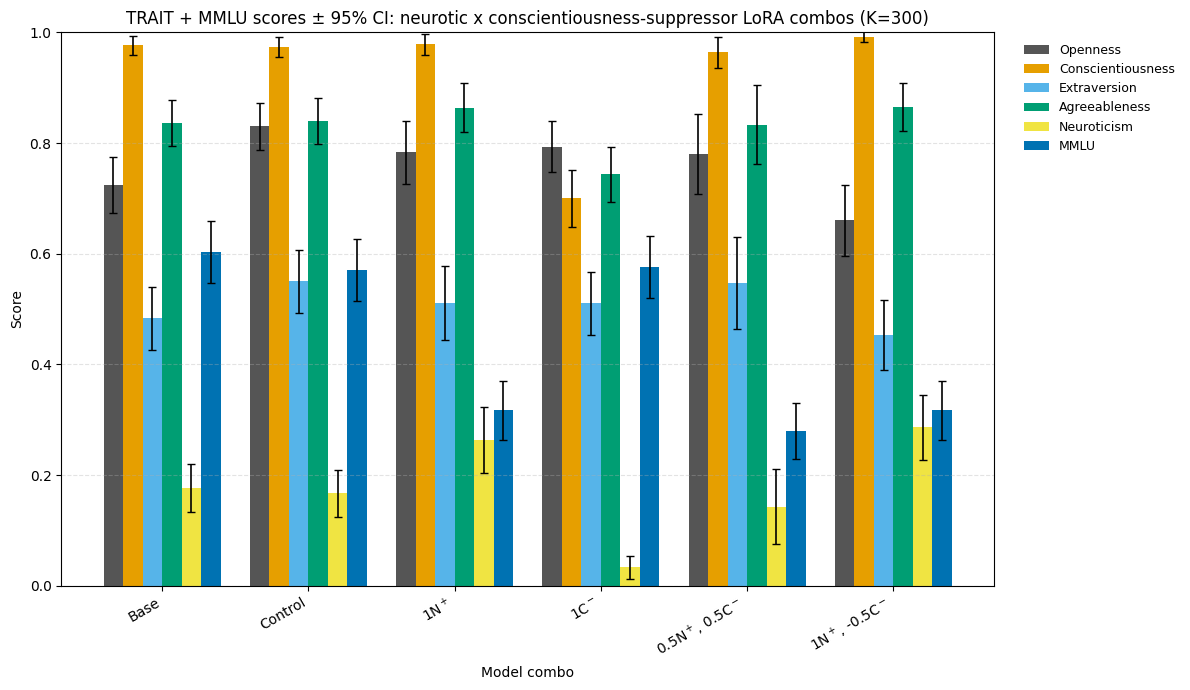

In [15]:
combo_labels = [label for _, label, _, _ in specific_model_entries]
trait_order = [t for t in PLOT_METRICS if t in set(summary_df["trait"])]
n_combos = len(combo_labels)
n_traits = len(trait_order)

plot_wide = summary_df.pivot(index="combo_label", columns="trait", values="score").reindex(combo_labels)
ci_wide = summary_df.pivot(index="combo_label", columns="trait", values="ci95").reindex(combo_labels)

COLORBLIND_PALETTE = ["#555555", "#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7", "#44AA99"]
colors = COLORBLIND_PALETTE[:n_traits]

width = 0.8 / n_traits
x = np.arange(n_combos)

fig, ax = plt.subplots(figsize=(max(10, 2.0 * n_combos), 7))
for i, trait in enumerate(trait_order):
    offset = (i - n_traits / 2 + 0.5) * width
    values = plot_wide[trait].values
    errors = ci_wide[trait].values
    ax.bar(x + offset, values, width=width, label=trait, color=colors[i],
           yerr=errors, capsize=3, error_kw={"elinewidth": 1.2, "ecolor": "black", "alpha": 1.0})

ax.set_ylabel("Score")
ax.set_xlabel("Model combo")
ax.set_ylim(0.0, 1.0)
ax.set_xticks(x)
ax.set_xticklabels(combo_labels, rotation=30, ha="right")
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, fontsize=9)
ax.set_title(f"TRAIT + MMLU scores ± 95% CI: neurotic x conscientiousness-suppressor LoRA combos (K={SAMPLES_PER_TRAIT})")

fig.tight_layout()

figures_dir = run_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
bar_path = figures_dir / "trait_combo_bar_chart.png"
fig.savefig(bar_path, dpi=200, bbox_inches="tight")
print(f"Saved: {bar_path}")
plt.show()


Saved: /root/persona-shattering-lasr/scratch/evals/trait_adapter_combinations/neuro_x_consc_combos/figures/trait_combo_bar_chart_by_trait.png


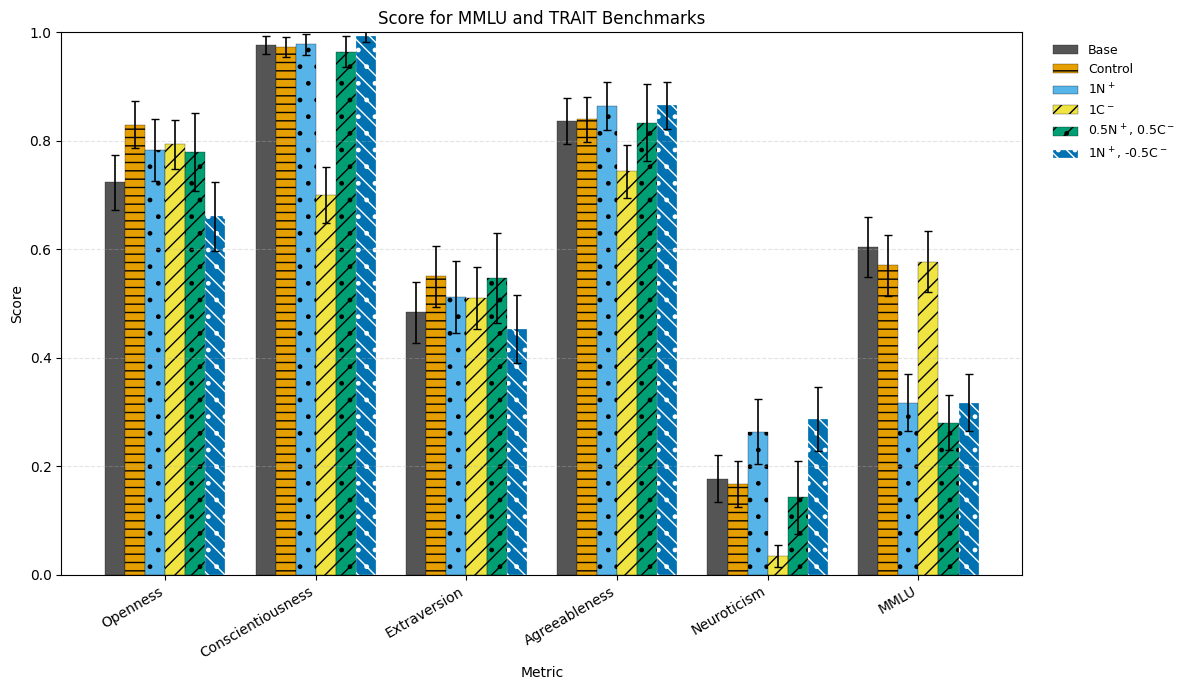

In [54]:
combo_labels = [label for _, label, _, _ in specific_model_entries]
trait_order = [t for t in PLOT_METRICS if t in set(summary_df["trait"])]
n_combos = len(combo_labels)
n_traits = len(trait_order)

# Pivot: traits on x-axis, combos as bar groups
plot_wide2 = summary_df.pivot(index="combo_label", columns="trait", values="score").reindex(combo_labels)
ci_wide2 = summary_df.pivot(index="combo_label", columns="trait", values="ci95").reindex(combo_labels)

COLORBLIND_PALETTE = ["#555555", "#E69F00", "#56B4E9", "#F0E442", "#009E73", "#0072B2", "#D55E00", "#CC79A7", "#44AA99"]
HATCHES = ['', '--', '.', '//', '//.', '\\\\.', '++', 'oo', '--', '|||']
colors2 = (COLORBLIND_PALETTE * ((n_combos // len(COLORBLIND_PALETTE)) + 1))[:n_combos]

width = 0.8 / n_combos
x = np.arange(n_traits)

fig, ax = plt.subplots(figsize=(max(10, 2.0 * n_traits), 7))
for i, label in enumerate(combo_labels):
    offset = (i - n_combos / 2 + 0.5) * width
    values = plot_wide2.loc[label, trait_order].values
    errors = ci_wide2.loc[label, trait_order].values
    bars = ax.bar(x + offset, values, width=width, label=label, color=colors2[i],
           hatch=HATCHES[i % len(HATCHES)],
           edgecolor='black',
           linewidth=0.2,
           yerr=errors, capsize=3, error_kw={"elinewidth": 1.2, "ecolor": "black", "alpha": 1.0})
    
for patch in bars.patches:
    patch.set_edgecolor('white')   # ← hatch color
        

ax.set_ylabel("Score")
ax.set_xlabel("Metric")
ax.set_ylim(0.0, 1.0)
ax.set_xticks(x)
ax.set_xticklabels(trait_order, rotation=30, ha="right")
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, fontsize=9)
ax.set_title(f"Score for MMLU and TRAIT Benchmarks")

fig.tight_layout()

bar2_path = figures_dir / "trait_combo_bar_chart_by_trait.png"
fig.savefig(bar2_path, dpi=200, bbox_inches="tight")
print(f"Saved: {bar2_path}")
plt.tight_layout()
plt.show()


## Heatmap

Saved: /root/persona-shattering-lasr/scratch/evals/trait_adapter_combinations/neuro_x_consc_combos/figures/trait_combo_heatmap.png


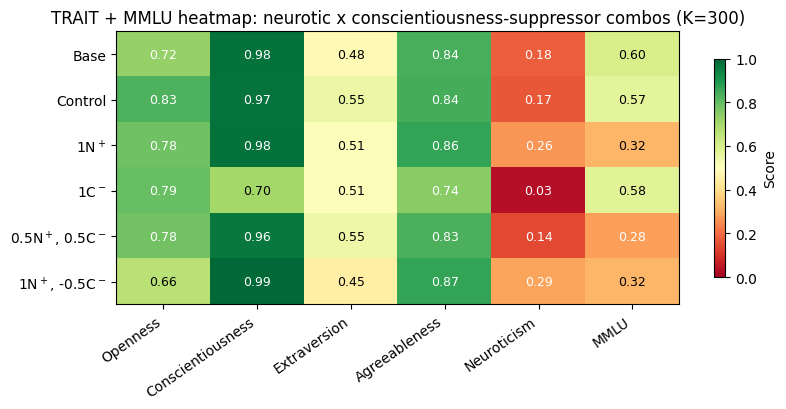

In [17]:
# plot_wide: index=combo_label, columns=traits — ready to use directly
heatmap_data = plot_wide[trait_order]  # ensure trait column order

fig, ax = plt.subplots(figsize=(max(8, n_traits * 1.4), max(4, n_combos * 0.7)))
im = ax.imshow(heatmap_data.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)

ax.set_xticks(range(n_traits))
ax.set_xticklabels(trait_order, rotation=35, ha="right")
ax.set_yticks(range(n_combos))
ax.set_yticklabels(combo_labels)

for i in range(n_combos):
    for j in range(n_traits):
        val = heatmap_data.values[i, j]
        text_color = "white" if val < 0.3 or val > 0.7 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9, color=text_color)

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Score")
ax.set_title(f"TRAIT + MMLU heatmap: neurotic x conscientiousness-suppressor combos (K={SAMPLES_PER_TRAIT})")

fig.tight_layout()

heatmap_path = figures_dir / "trait_combo_heatmap.png"
fig.savefig(heatmap_path, dpi=200, bbox_inches="tight")
print(f"Saved: {heatmap_path}")
plt.show()

In [11]:
from huggingface_hub import HfApi

api = HfApi()
api.upload_folder(
    folder_path=str(REPO_ROOT / "scratch/evals/trait_adapter_combinations/neuro_x_consc_combos"),
    path_in_repo="evals/trait_mmlu_evals/neuro_x_consc_combos",
    repo_id="persona-shattering-lasr/monorepo",
    repo_type="dataset",
)
print("Upload complete") 

It seems you are trying to upload a large folder at once. This might take some time and then fail if the folder is too large. For such cases, it is recommended to upload in smaller batches or to use `HfApi().upload_large_folder(...)`/`hf upload-large-folder` instead. For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/upload#upload-a-large-folder.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Upload complete
